In [1]:
import sys
import os

path = os.path.abspath(os.path.join(os.getcwd(), "../"))
sys.path.insert(0, path)
from tdaphantom.tdaphantom import Phantom
PRECOMPUTED_DIR = "./precomputed"

In [2]:
from ripser import ripser
from scipy.spatial.distance import cdist
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def _make_disk(n=2000, seed=0):
    rng = np.random.default_rng(seed)
    pts = []
    while len(pts) < n:
        b = rng.uniform(-1, 1, (n * 4, 2))
        pts.append(b[np.linalg.norm(b, axis=1) <= 1.0])
    return np.vstack(pts)[:n]


def _make_circle(n=2000, noise=0.03, seed=1):
    rng   = np.random.default_rng(seed)
    theta = rng.uniform(0, 2 * np.pi, n)
    pts   = np.stack([np.cos(theta), np.sin(theta)], axis=1)
    return pts + rng.normal(0, noise, pts.shape)


def _make_torus(n=2000, R=5.0, r=3.0, seed=2):
    rng   = np.random.default_rng(seed)
    theta = rng.uniform(0, 2 * np.pi, n)
    phi_list = []
    while len(phi_list) < n:
        phi_c = rng.uniform(0, 2 * np.pi, n * 2)
        w     = (R + r * np.cos(phi_c)) / (R + r)
        phi_list.append(phi_c[rng.uniform(0, 1, len(phi_c)) < w])
    phi = np.concatenate(phi_list)[:n]
    x   = (R + r * np.cos(phi)) * np.cos(theta)
    y   = (R + r * np.cos(phi)) * np.sin(theta)
    z   =  r * np.sin(phi)
    return np.stack([x, y, z], axis=1)



In [4]:
def _ripser_h1(pts):
    D   = cdist(pts, pts)
    dgm = ripser(D, distance_matrix=True, maxdim=1)["dgms"][1]
    # ripser may return bars with birth == death, strip them
    return dgm[dgm[:, 1] > dgm[:, 0]]



In [5]:
def _load_or_compute_dgm(name: str, pts_fn, ripser_fn) -> np.ndarray:
    """
    Load a precomputed persistence diagram from disk if it exists,
    otherwise compute it, save it, and return it.
    """
    os.makedirs(PRECOMPUTED_DIR, exist_ok=True)
    path = os.path.join(PRECOMPUTED_DIR, f"dgm_{name}.txt")

    if os.path.exists(path):
        print(f"  Loading precomputed {name} diagram from {path}")
        return np.loadtxt(path)
    else:
        print(f"  Computing {name} diagram (may take a while)...")
        pts = pts_fn()
        dgm = ripser_fn(pts)
        np.savetxt(path, dgm)
        print(f"  Saved to {path}")
        return dgm


dgm_disk   = _load_or_compute_dgm("disk",   _make_disk,   _ripser_h1)
dgm_circle = _load_or_compute_dgm("circle", _make_circle, _ripser_h1)
dgm_torus  = _load_or_compute_dgm("torus",  _make_torus,  _ripser_h1)


print(f"Disk   — H_1 bars: {len(dgm_disk)}")
print(f"Circle — H_1 bars: {len(dgm_circle)}")
print(f"Torus  — H_1 bars: {len(dgm_torus)}")

phantom_disk   = Phantom(dgm_disk,   k=1)
phantom_circle = Phantom(dgm_circle, k=1)
phantom_torus  = Phantom(dgm_torus,  k=1)

print(phantom_disk)
print(phantom_circle)
print(phantom_torus)

  Loading precomputed disk diagram from ./precomputed/dgm_disk.txt
  Loading precomputed circle diagram from ./precomputed/dgm_circle.txt
  Loading precomputed torus diagram from ./precomputed/dgm_torus.txt
Disk   — H_1 bars: 520
Circle — H_1 bars: 388
Torus  — H_1 bars: 533
Phantom(H_1, 520 bars: 520 finite, 0 infinite)
Phantom(H_1, 388 bars: 388 finite, 0 infinite)
Phantom(H_1, 533 bars: 533 finite, 0 infinite)


alpha_thresh : 0.01
L_hat        : -1.8623148860981824
A            : 1
B            : 1.2850992211966523
l_thresh     : 1.5271796258079011
rejected by p_value : 0
above pi threshold  : 0
match               : True
alpha_thresh : 0.01
L_hat        : -2.1521344533073217
A            : 1
B            : 1.5749187884057916
l_thresh     : 1.5271796258079011
rejected by p_value : 1
above pi threshold  : 1
match               : True
alpha_thresh : 0.01
L_hat        : -1.7789611965645802
A            : 1
B            : 1.2017455316630503
l_thresh     : 1.5271796258079011
rejected by p_value : 2
above pi threshold  : 2
match               : True


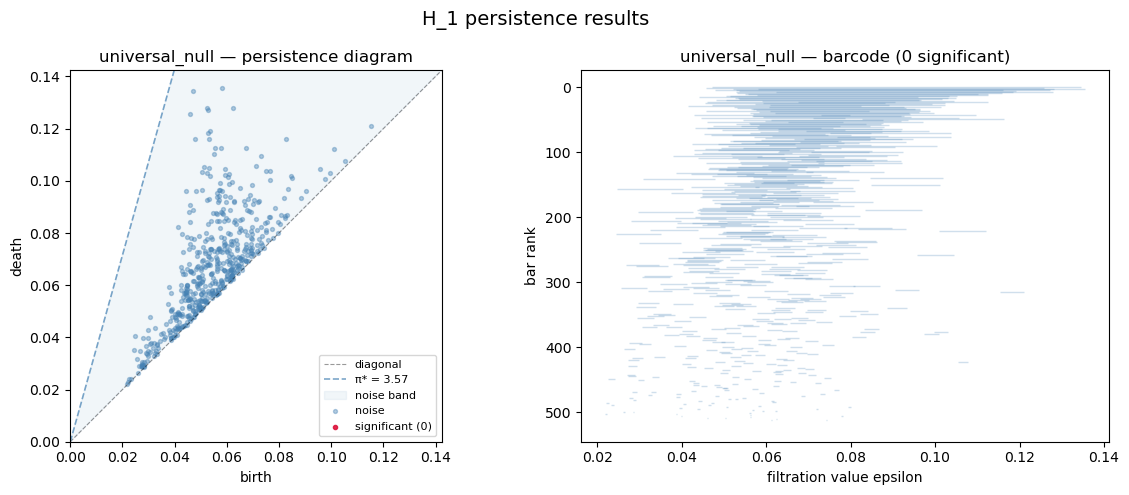

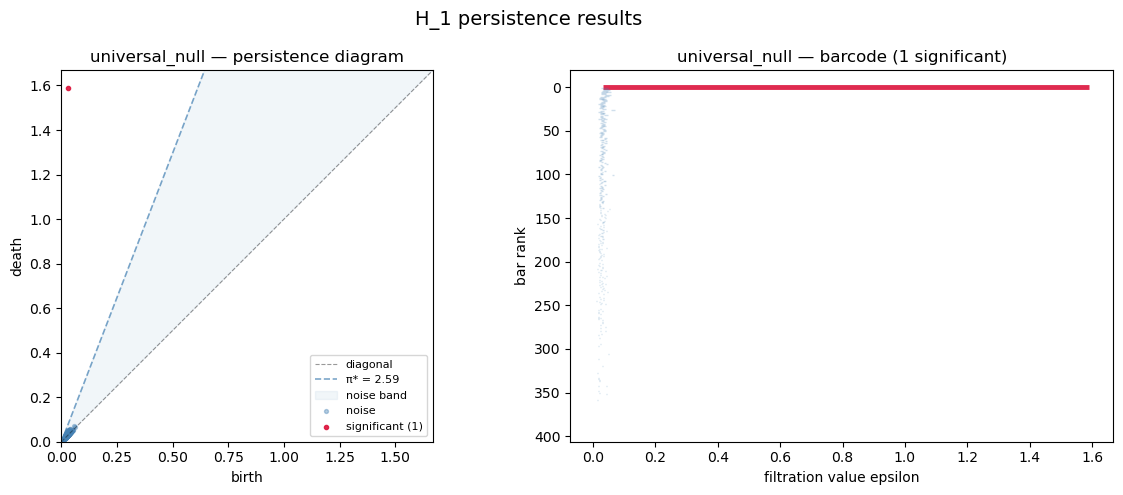

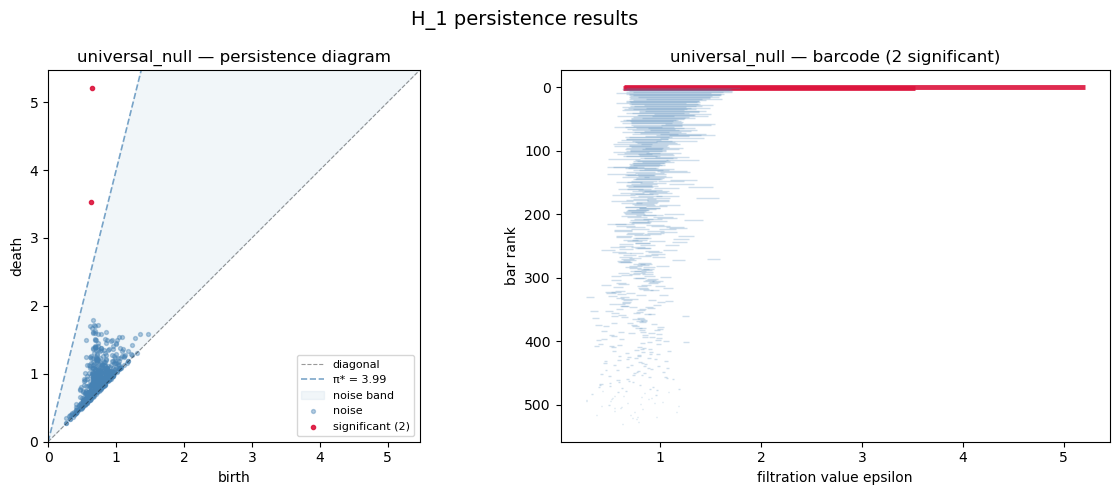

In [7]:
alpha = 0.01
correction = "BH"
method = ["universal_null"]
results_disk   = phantom_disk.hypothesis_test(alpha,correction_method=correction,methods=method)
results_circle = phantom_circle.hypothesis_test(alpha,correction_method=correction,methods=method)
results_torus  = phantom_torus.hypothesis_test(alpha,correction_method=correction,methods=method)

phantom_disk.display_results()
phantom_circle.display_results()
phantom_torus.display_results()